In [2]:
import os
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from time import sleep
from dateutil import parser
from dotenv import load_dotenv
import json

In [10]:
# Calculate the information of stanford 
lat=latitude = '37.4277'
lon=longitude = '-122.1701'
USER_AGENT = {"User-Agent": "Pikachu"}

url = f'https://api.weather.gov/points/{latitude},{longitude}'
response = requests.get(url, headers=USER_AGENT).json()

# Display response from API
office = response["properties"]["gridId"]
gridX = response["properties"]["gridX"]
gridY = response["properties"]["gridY"]

In [4]:
url = f"https://api.weather.gov/gridpoints/{office}/{gridX},{gridY}"
data = requests.get(url, headers=USER_AGENT).json()

with open("raw.json", "w") as file:
    json.dump(data, file)

In [6]:
def getHourlyForecast(latitude, longitude, user_agent):
    points_data = requests.get(
        f'https://api.weather.gov/points/{latitude},{longitude}',
        headers=user_agent
    ).json()
    office = points_data["properties"]["gridId"]
    gridX = points_data["properties"]["gridX"]
    gridY = points_data["properties"]["gridY"]

    sleep(1)    # Add 1 second delay between API requests

    # The "/hourly" is the only difference between the hourly and daily forecast URLs
    gridpoints_data = requests.get(
        f'https://api.weather.gov/gridpoints/{office}/{gridX},{gridY}/forecast/hourly',
        headers=user_agent
    ).json()
    return gridpoints_data

In [7]:
hourlyForecast = getHourlyForecast(latitude, longitude, USER_AGENT)
with open("forecast.json", "w") as file:
    json.dump(hourlyForecast, file)

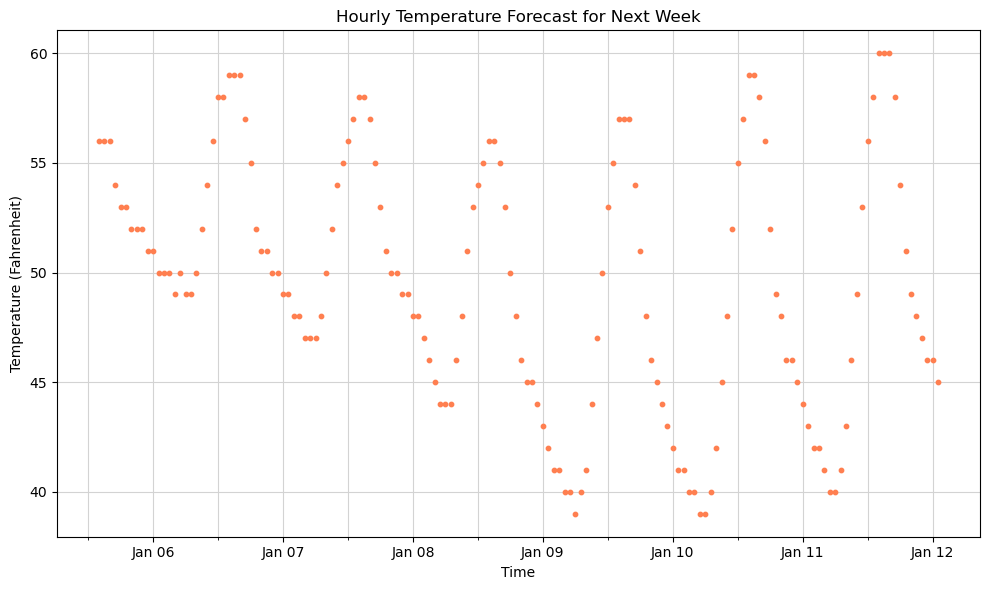

In [8]:
hours = []
temperatures = []
for hourForecast in hourlyForecast["properties"]["periods"]:
    hour = parser.parse(hourForecast["startTime"][:19])
    hours.append(hour)
    temperatures.append(hourForecast["temperature"])

plt.figure(figsize=(10, 6))
plt.scatter(hours, temperatures, color='coral', marker='o', s=10)
plt.title('Hourly Temperature Forecast for Next Week')
plt.xlabel('Time')
plt.ylabel('Temperature (Fahrenheit)')
plt.grid(True, which='both', color='lightgray')
plt.gca().set_axisbelow(True)
plt.gca().xaxis.set_major_locator(mdates.HourLocator(byhour=0))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_minor_locator(mdates.HourLocator(byhour=12))
plt.gca().xaxis.set_minor_formatter(mdates.DateFormatter(''))
plt.tight_layout()
plt.show()

In [14]:
# points API
points = requests.get(
    f"https://api.weather.gov/points/{lat},{lon}",
    headers=USER_AGENT
).json()

sleep(1)

stations_url = points["properties"]["observationStations"]
stations = requests.get(
    stations_url,
    headers=USER_AGENT
).json()


stations["features"][0]["properties"]
station_id = stations["features"][0]["properties"]["stationIdentifier"]

sleep(1)


observe = requests.get(
    f"https://api.weather.gov/stations/{station_id}/observations/latest",
    headers=USER_AGENT,
).json()

with open("observe.json", "w") as file:
    json.dump(observe, file)